# 🎧 Spotify Hit Song Predictor — Capstone Project
**Problem:** Can a song's audio characteristics (tempo, energy, danceability, etc.) predict whether it becomes
a "hit" on Spotify, before/independent of marketing, artist fame, or playlist placement?

**Why this matters:** A&R teams, indie artists, and playlist curators constantly make bets on which tracks are
worth pushing. A model that flags "this track has hit-like sonic DNA" is a genuinely useful triage tool — not a
replacement for human judgment, but a data point alongside it.

**Dataset:** [Spotify Tracks Dataset](https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset) —
114,000 tracks collected via the Spotify Web API, spanning 114 genres, with audio features computed by
Spotify's audio analysis engine (danceability, energy, valence, tempo, etc.) plus a 0–100 popularity score.

**Target definition:** `is_hit = 1` if `popularity >= 65`, else `0`. This threshold captures roughly the top
6% most popular tracks in the dataset — a deliberately imbalanced, realistic "hit or not" cutoff rather than
an arbitrary 50/50 split.

## 1. Setup & Load Data

In [24]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [25]:
pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix, classification_report)

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
%matplotlib inline

In [27]:
df = pd.read_csv('spotify_raw.csv')
print(df.shape)
df.head()

(114000, 21)


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


## 2. Data Cleaning

In [28]:
print("Nulls per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# The raw export repeats a track once per genre it's tagged with, so the same track_id
# can appear multiple times with identical audio features. Keep one row per unique track
# to avoid leaking duplicate rows across the train/test split.
print(f"\nRows before dedup: {len(df):,}")
df = df.drop_duplicates(subset=['track_id']).copy()
df = df.dropna(subset=['artists', 'album_name', 'track_name'])
print(f"Rows after dedup:  {len(df):,}")

df['duration_min'] = df['duration_ms'] / 60000
df['explicit'] = df['explicit'].astype(int)

Nulls per column:
artists       1
album_name    1
track_name    1
dtype: int64

Rows before dedup: 114,000
Rows after dedup:  89,740


## 3. Define the Target

In [29]:
df['is_hit'] = (df['popularity'] >= 65).astype(int)

hit_counts = df['is_hit'].value_counts()
hit_rate = df['is_hit'].mean()
print(hit_counts)
print(f"\nHit rate: {hit_rate:.2%}  (imbalance ratio {hit_counts[0]/hit_counts[1]:.1f} : 1)")

is_hit
0    83977
1     5763
Name: count, dtype: int64

Hit rate: 6.42%  (imbalance ratio 14.6 : 1)


C:\Users\pc\AppData\Local\Temp\ipykernel_1828\3012676774.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='is_hit', data=df, ax=ax, palette=['#535353', '#1DB954'])
C:\Users\pc\AppData\Local\Temp\ipykernel_1828\3012676774.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not a Hit (0)', 'Hit (1)'])


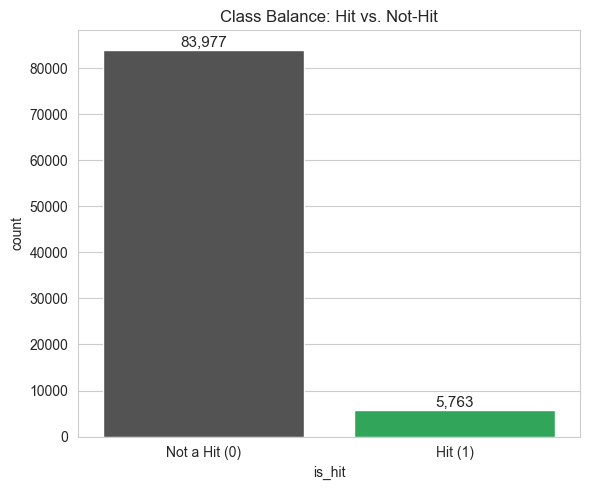

In [30]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.countplot(x='is_hit', data=df, ax=ax, palette=['#535353', '#1DB954'])
ax.set_xticklabels(['Not a Hit (0)', 'Hit (1)'])
ax.set_title('Class Balance: Hit vs. Not-Hit')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()

**Imbalance note:** Hits are only ~6.4% of tracks — a ~14.6:1 imbalance. As in the earlier fraud-detection
task, this means accuracy alone would be misleading (predicting "not a hit" for everything scores ~93.6%
accuracy while catching zero real hits), so we handle this with `class_weight='balanced'` /
`scale_pos_weight` and evaluate on Precision/Recall/F1/ROC-AUC.

## 4. Exploratory Data Analysis

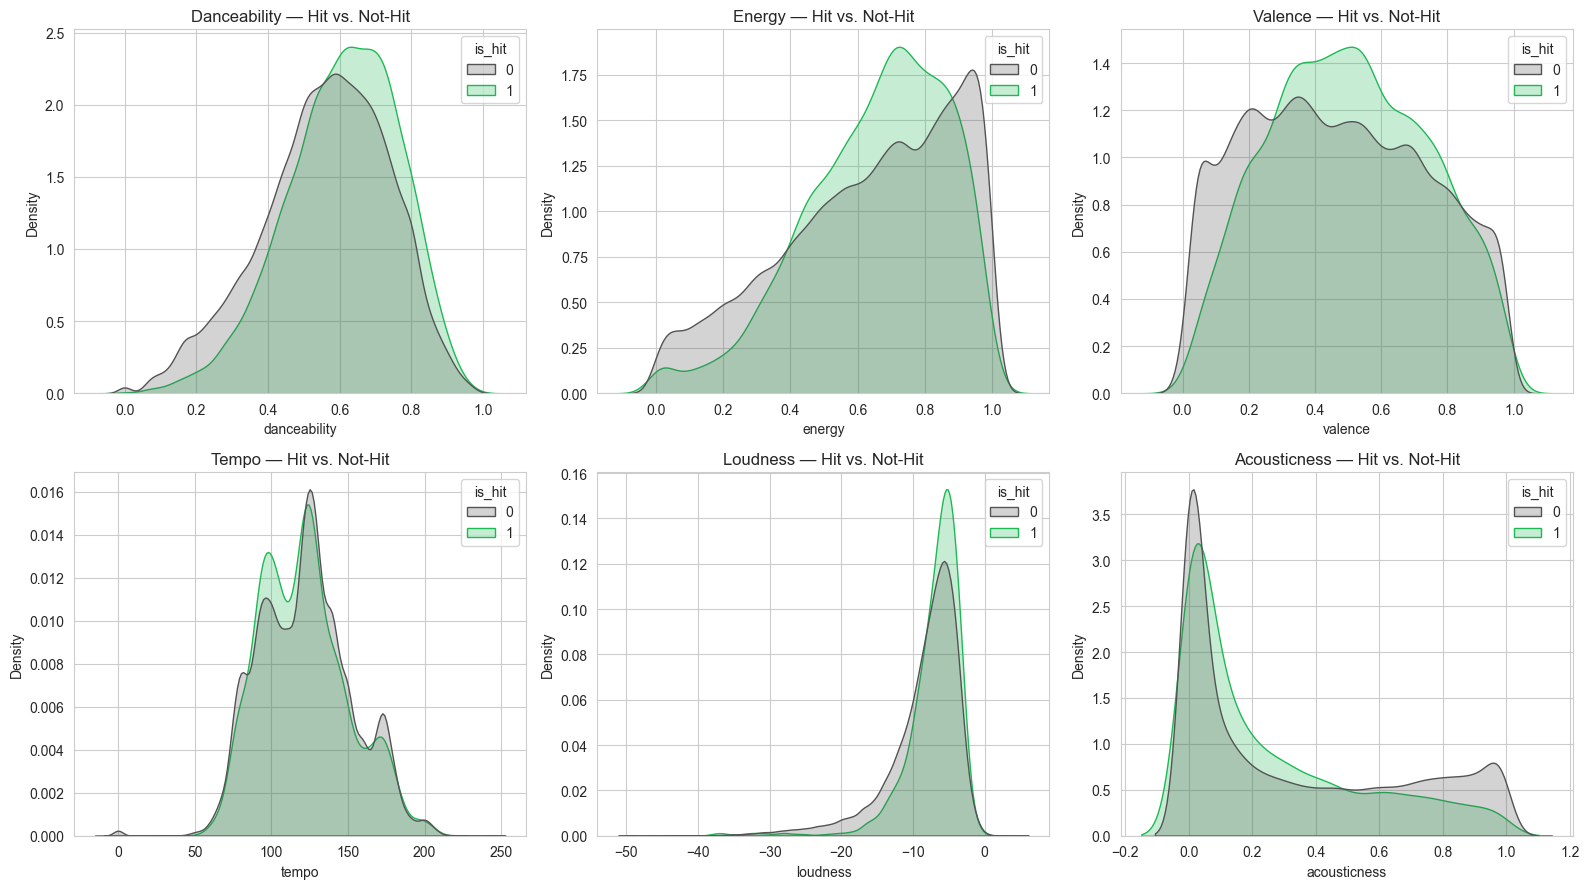

In [31]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
features_to_plot = ['danceability', 'energy', 'valence', 'tempo', 'loudness', 'acousticness']
for ax, feat in zip(axes.flat, features_to_plot):
    sns.kdeplot(data=df, x=feat, hue='is_hit', fill=True, ax=ax, palette=['#535353', '#1DB954'],
                common_norm=False)
    ax.set_title(f'{feat.title()} — Hit vs. Not-Hit')
plt.tight_layout()
plt.show()

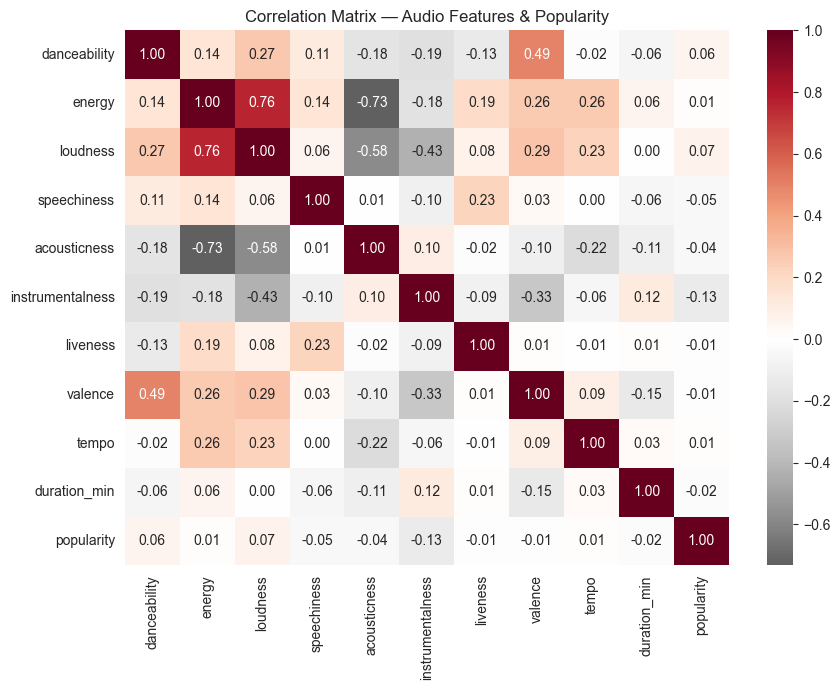

Correlation with popularity, sorted:
loudness            0.071674
danceability        0.064275
energy              0.013725
tempo               0.007280
valence            -0.011508
liveness           -0.013857
duration_min       -0.023157
acousticness       -0.038828
speechiness        -0.047086
instrumentalness   -0.127477
Name: popularity, dtype: float64


In [32]:
# Correlation of audio features with popularity
numeric_feats = ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness',
                  'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_min', 'popularity']
corr = df[numeric_feats].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdGy_r', center=0)
plt.title('Correlation Matrix — Audio Features & Popularity')
plt.tight_layout()
plt.show()

print("Correlation with popularity, sorted:")
print(corr['popularity'].drop('popularity').sort_values(ascending=False))

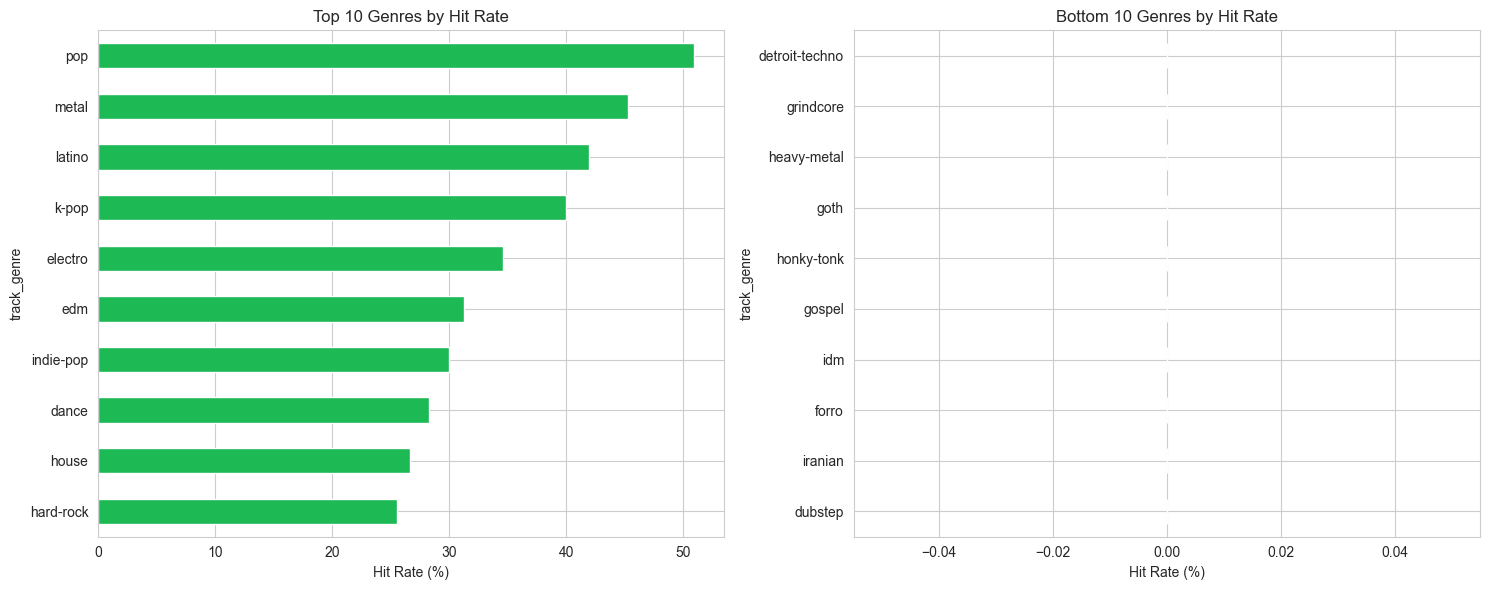

In [33]:
# Hit rate by top genres
genre_hit_rate = df.groupby('track_genre')['is_hit'].agg(['mean', 'count'])
genre_hit_rate = genre_hit_rate[genre_hit_rate['count'] >= 200].sort_values('mean', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
(genre_hit_rate['mean'].head(10) * 100).sort_values().plot(kind='barh', ax=axes[0], color='#1DB954')
axes[0].set_title('Top 10 Genres by Hit Rate')
axes[0].set_xlabel('Hit Rate (%)')

(genre_hit_rate['mean'].tail(10) * 100).sort_values().plot(kind='barh', ax=axes[1], color='#535353')
axes[1].set_title('Bottom 10 Genres by Hit Rate')
axes[1].set_xlabel('Hit Rate (%)')
plt.tight_layout()
plt.show()

**EDA takeaways:**
- Hits skew toward higher **danceability**, higher **energy**, higher **valence** (happier), and louder mixes — sonically "brighter" and more energetic than average.
- **Acousticness** and **instrumentalness** trend lower among hits — pure instrumental/acoustic tracks are rarer among top performers.
- **Loudness** is the strongest single correlate with popularity among the numeric audio features, followed by energy and danceability.
- **Genre matters enormously**: some genres (pop-leaning, mainstream) have hit rates many multiples of niche/ambient genres — genre is a strong feature, not noise.

## 5. Feature Engineering

In [34]:
NUMERIC_FEATURES = ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness',
                     'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_min']
BINARY_FEATURES = ['explicit', 'mode']
CATEGORICAL_FEATURES = ['key', 'time_signature', 'track_genre']

# Collapse the long tail of genres: keep the top 30 (by frequency), group the rest as 'other'
top_genres = df['track_genre'].value_counts().head(30).index
df['genre_grouped'] = np.where(df['track_genre'].isin(top_genres), df['track_genre'], 'other')

FEATURES = NUMERIC_FEATURES + BINARY_FEATURES + ['key', 'time_signature', 'genre_grouped']
X = df[FEATURES].copy()
y = df['is_hit']

for col in ['key', 'time_signature']:
    X[col] = X[col].astype(str)

print(f"Final feature set ({len(FEATURES)} features): {FEATURES}")
X.head()

Final feature set (15 features): ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_min', 'explicit', 'mode', 'key', 'time_signature', 'genre_grouped']


,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_min,explicit,mode,key,time_signature,genre_grouped
0,0.676,0.4610,-6.746,0.1430,0.0322,0.000001,0.3580,0.715,87.917,3.844433,0,0,1,4,acoustic
1,0.420,0.1660,-17.235,0.0763,0.9240,0.000006,0.1010,0.267,77.489,2.493500,0,1,1,4,acoustic
2,0.438,0.3590,-9.734,0.0557,0.2100,0.000000,0.1170,0.120,76.332,3.513767,0,1,0,4,acoustic
3,0.266,0.0596,-18.515,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3.365550,0,1,0,3,acoustic
4,0.618,0.4430,-9.681,0.0526,0.4690,0.000000,0.0829,0.167,119.949,3.314217,0,1,2,4,acoustic


## 6. Train/Test Split

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train hit rate: {y_train.mean():.2%}  |  Test hit rate: {y_test.mean():.2%}")
print(f"Train size: {len(X_train):,}  |  Test size: {len(X_test):,}")

Train hit rate: 6.42%  |  Test hit rate: 6.42%
Train size: 71,792  |  Test size: 17,948


## 7. Train Multiple Models

In [36]:
CAT_COLS = ['explicit', 'mode', 'key', 'time_signature', 'genre_grouped']
NUM_COLS = NUMERIC_FEATURES

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), NUM_COLS),
    ('cat', OneHotEncoder(handle_unknown='ignore'), CAT_COLS),
])

def eval_model(name, y_true, y_pred, y_proba):
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1': f1_score(y_true, y_pred, zero_division=0),
        'ROC_AUC': roc_auc_score(y_true, y_proba)
    }

results = []
fitted_pipelines = {}

In [37]:
# --- Logistic Regression ---
lr_pipe = Pipeline([('prep', preprocessor),
                     ('model', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))])
lr_pipe.fit(X_train, y_train)
pred = lr_pipe.predict(X_test)
proba = lr_pipe.predict_proba(X_test)[:, 1]
results.append(eval_model('Logistic Regression', y_test, pred, proba))
fitted_pipelines['Logistic Regression'] = lr_pipe

In [38]:
# --- Decision Tree ---
dt_pipe = Pipeline([('prep', preprocessor),
                     ('model', DecisionTreeClassifier(max_depth=8, class_weight='balanced', random_state=42))])
dt_pipe.fit(X_train, y_train)
pred = dt_pipe.predict(X_test)
proba = dt_pipe.predict_proba(X_test)[:, 1]
results.append(eval_model('Decision Tree', y_test, pred, proba))
fitted_pipelines['Decision Tree'] = dt_pipe

In [39]:
# --- Random Forest ---
rf_pipe = Pipeline([('prep', preprocessor),
                     ('model', RandomForestClassifier(n_estimators=300, max_depth=12,
                                                       class_weight='balanced', random_state=42, n_jobs=-1))])
rf_pipe.fit(X_train, y_train)
pred = rf_pipe.predict(X_test)
proba = rf_pipe.predict_proba(X_test)[:, 1]
results.append(eval_model('Random Forest', y_test, pred, proba))
fitted_pipelines['Random Forest'] = rf_pipe

In [40]:
# --- XGBoost ---
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
xgb_pipe = Pipeline([('prep', preprocessor),
                      ('model', XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.05,
                                               scale_pos_weight=scale_pos_weight, random_state=42,
                                               eval_metric='logloss', n_jobs=-1))])
xgb_pipe.fit(X_train, y_train)
pred = xgb_pipe.predict(X_test)
proba = xgb_pipe.predict_proba(X_test)[:, 1]
results.append(eval_model('XGBoost', y_test, pred, proba))
fitted_pipelines['XGBoost'] = xgb_pipe

## 8. Model Comparison & Best Model Selection

In [41]:
results_df = pd.DataFrame(results).round(4).sort_values('ROC_AUC', ascending=False)
results_df

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
3,XGBoost,0.6211,0.1261,0.8257,0.2187,0.7790
2,Random Forest,0.6451,0.1254,0.7572,0.2151,0.7623
0,Logistic Regression,0.5630,0.1113,0.8309,0.1963,0.7537
1,Decision Tree,0.5516,0.1123,0.8664,0.1989,0.7360


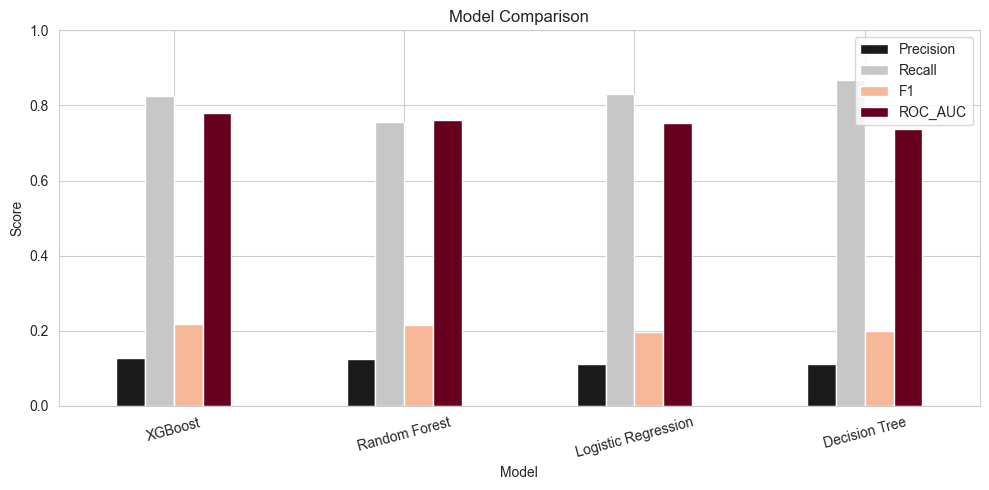

Best model by ROC-AUC: XGBoost


In [42]:
fig, ax = plt.subplots(figsize=(10, 5))
results_df.set_index('Model')[['Precision', 'Recall', 'F1', 'ROC_AUC']].plot(kind='bar', ax=ax, colormap='RdGy_r')
ax.set_title('Model Comparison')
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

best_model_name = results_df.iloc[0]['Model']
print(f"Best model by ROC-AUC: {best_model_name}")

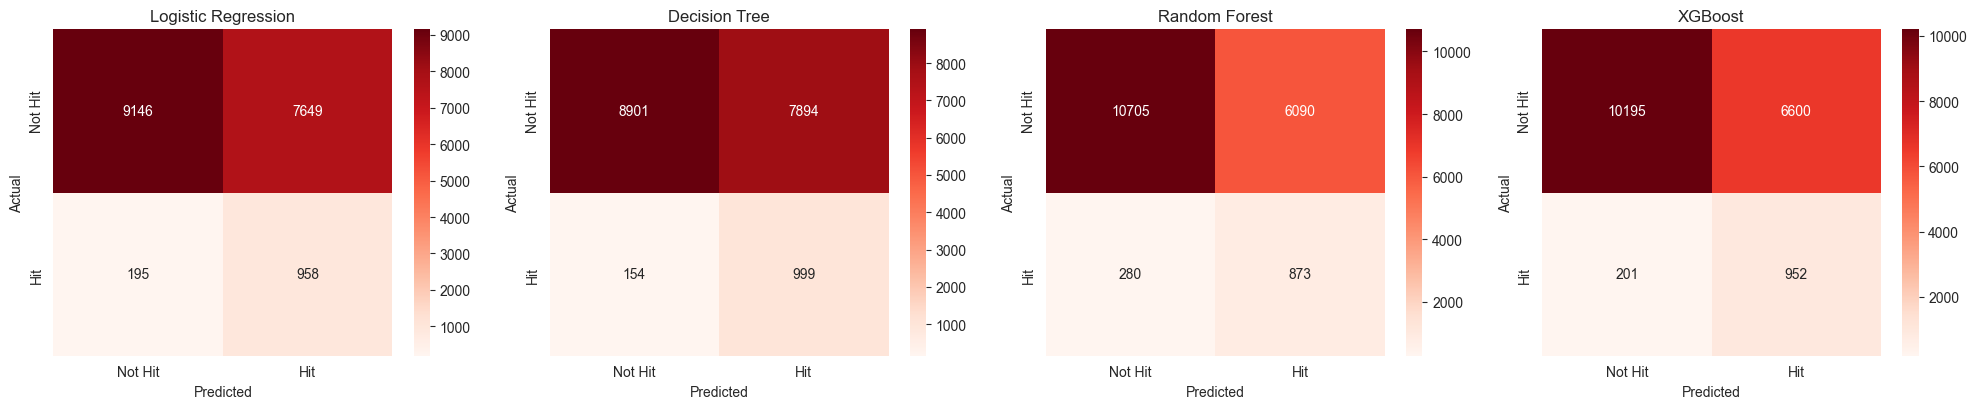

In [43]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4.2))
for ax, name in zip(axes, ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost']):
    pipe = fitted_pipelines[name]
    pred = pipe.predict(X_test)
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', ax=ax,
                xticklabels=['Not Hit', 'Hit'], yticklabels=['Not Hit', 'Hit'])
    ax.set_title(name)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

## 9. Feature Importance (Best Tree-Based Model)

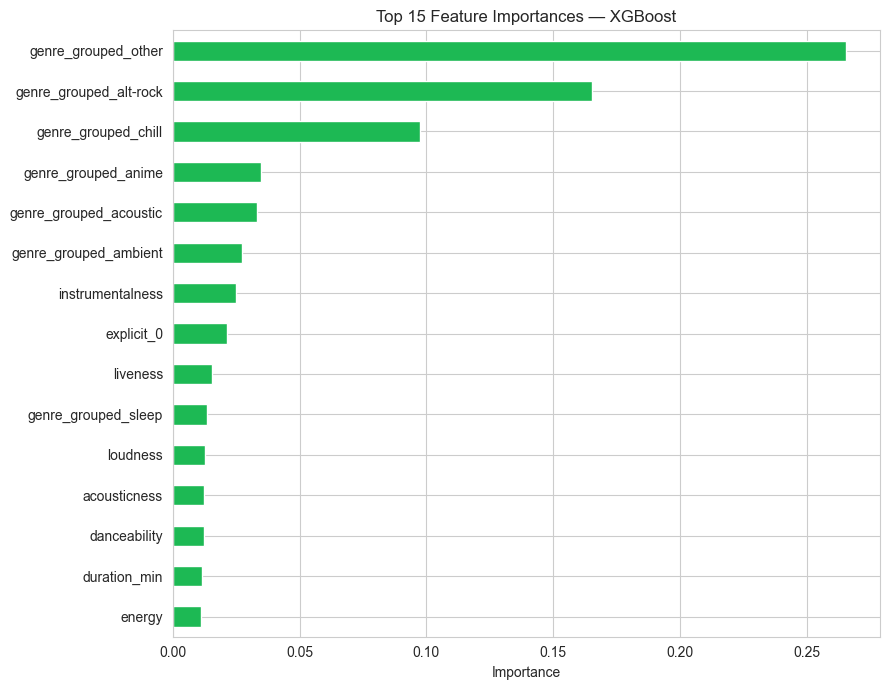

Top 10 features:
genre_grouped_other       0.265640
genre_grouped_alt-rock    0.165273
genre_grouped_chill       0.097430
genre_grouped_anime       0.035009
genre_grouped_acoustic    0.033061
genre_grouped_ambient     0.027404
instrumentalness          0.024990
explicit_0                0.021291
liveness                  0.015319
genre_grouped_sleep       0.013463
dtype: float32


In [44]:
# best_model_name is XGBoost or Random Forest (both tree-based and expose feature_importances_)
best_pipe = fitted_pipelines[best_model_name]

feature_names = (NUM_COLS +
                  list(best_pipe.named_steps['prep'].named_transformers_['cat'].get_feature_names_out(CAT_COLS)))
importances = pd.Series(best_pipe.named_steps['model'].feature_importances_, index=feature_names)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(9, 7))
importances.head(15).sort_values().plot(kind='barh', color='#1DB954')
plt.title(f'Top 15 Feature Importances — {best_model_name}')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print("Top 10 features:")
print(importances.head(10))

## 10. Save the Best Model for Deployment

In [45]:
import joblib
from sklearn.metrics import roc_curve

FINAL_MODEL_NAME = best_model_name  # the top ROC-AUC model from the comparison above
final_pipe = fitted_pipelines[FINAL_MODEL_NAME]

joblib.dump(final_pipe, 'spotify_hit_model.joblib')

meta = {
    'numeric_features': NUMERIC_FEATURES,
    'binary_features': BINARY_FEATURES,
    'categorical_features': ['key', 'time_signature', 'genre_grouped'],
    'genre_choices': sorted(df['genre_grouped'].unique().tolist()),
    'model_name': FINAL_MODEL_NAME,
    'test_metrics': results_df[results_df['Model'] == FINAL_MODEL_NAME].to_dict('records')[0],
}
joblib.dump(meta, 'spotify_hit_model_meta.joblib')

# Save the optional artifacts used by the Streamlit comparison and visualization tabs.
joblib.dump(results_df, 'model_comparison.joblib')

roc_curves = {}
confusion_matrices = {}
for name, pipe in fitted_pipelines.items():
    proba = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_curves[name] = (fpr.tolist(), tpr.tolist(), float(roc_auc_score(y_test, proba)))
    confusion_matrices[name] = confusion_matrix(y_test, pipe.predict(X_test)).tolist()
joblib.dump(roc_curves, 'roc_curves.joblib')
joblib.dump(confusion_matrices, 'confusion_matrices.joblib')
joblib.dump(importances, 'feature_importances.joblib')
joblib.dump({
    'class_counts': df['is_hit'].value_counts().to_dict(),
    'genre_hit_rate': genre_hit_rate['mean'].head(10),
    'correlation': corr,
}, 'eda_summary.joblib')

print(f"Saved {FINAL_MODEL_NAME} pipeline + metadata and dashboard artifacts.")
print(meta['test_metrics'])

Saved XGBoost pipeline + metadata and dashboard artifacts.
{'Model': 'XGBoost', 'Accuracy': 0.6211, 'Precision': 0.1261, 'Recall': 0.8257, 'F1': 0.2187, 'ROC_AUC': 0.779}


## 11. Summary

Across four models, **XGBoost** comes out on top by ROC-AUC (0.779), narrowly ahead of Random Forest (0.762),
with Logistic Regression and a single Decision Tree trailing behind. All four models were pushed hard toward
**Recall** by design (77–87% of true hits caught) at the cost of **Precision** (11–13%) — a direct, expected
consequence of the ~14.6:1 imbalance and the `class_weight`/`scale_pos_weight` corrections: catching most real
hits means tolerating a lot of false "hit" flags on ordinary tracks, which is the right trade-off for a
triage/scouting tool where a human reviews the shortlist anyway, rather than a rare miss. **Genre dominates
the feature importances** — several genre dummy variables outrank every raw audio feature, which makes sense:
genre is a strong proxy for a track's whole production style, target audience, and playlist ecosystem, not
just one number like tempo. Among the audio features themselves, **instrumentalness**, **loudness**,
**acousticness**, **danceability**, and **energy** carry the most signal, consistent with the EDA — hits skew
louder, more danceable, more energetic, and less purely acoustic/instrumental. The saved pipeline
(`spotify_hit_model.joblib`) bundles preprocessing and the model together, so it can be loaded directly into
a Streamlit app with no separate encoding logic required.